# Result 3 — The misalignment between research attention and driver impact is consistent across ecosystem realms

**Question:** how are the five IPBES direct drivers distributed across the scientific
articles assigned to each ecosystem realm, and does that distribution track the driver
hierarchy global assessments report for each realm?

The unit is one publication. The analysis retains negative-impact records from complete
years 2000–2025 carrying exactly one of the 10 ecological L4 realm labels;
`Not Applicable`, `All realms`, and records with multiple distinct realm labels are
excluded and audited. Each publication contributes total weight one, divided equally
across the IPBES L1 drivers it names, so realm columns sum to 100%.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (candidate / "data_helpers").is_dir() and (candidate / "checklists").is_dir():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the biodiversity repository root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
from data_helpers import results_config, visualization
from data_helpers.analysis.realm import driver as driver_realm
from data_helpers.analysis.realm import driver_plotting as driver_realm_plotting
from data_helpers.prep import evidence_corpus_prep

In [4]:
visualization.apply_style()

RESULTS_CONFIG = results_config.load_results_config()
REALM_CONFIG = RESULTS_CONFIG["driver_realm"]
EVIDENCE_CONFIG = RESULTS_CONFIG["biodiversity_evidence_prep"]
DRIVER_CATALOG, DRIVER_COLORS, DRIVER_NAMES = results_config.driver_l1_display(
    RESULTS_CONFIG
)
DRIVER_ORDER = tuple(results_config.driver_l1_stack_order(RESULTS_CONFIG))

REALM_ORDER = tuple(REALM_CONFIG["analysis_realms"])
CORE_REALMS = tuple(REALM_CONFIG["core_realms"])
REALM_NAMES = REALM_CONFIG["realm_display_names"]
REALM_SHORT_NAMES = REALM_CONFIG["realm_short_names"]
START_YEAR = REALM_CONFIG["primary_start_year"]
END_YEAR = REALM_CONFIG["primary_end_year"]
CORE_REALM_COLORS = {
    "Terrestrial": "#E69F00",
    "Freshwater": "#009E73",
    "Marine": "#0072B2",
}
PLASTICS_PATTERN = driver_realm.DEFAULT_PLASTICS_PATTERN

CORPUS_DIR = PROJECT_ROOT / EVIDENCE_CONFIG["output_directory"]

OUTPUT_DIR = PROJECT_ROOT / REALM_CONFIG["output_directory"]
TABLE_DIR = OUTPUT_DIR / REALM_CONFIG["table_subdirectory"]
FIGURE_DIR = OUTPUT_DIR / REALM_CONFIG["figure_subdirectory"]
for directory in (TABLE_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

# Provenance: the complete set of inputs this result depends on.
status = "found" if CORPUS_DIR.exists() else "MISSING"
print(f"Input   evidence corpus  {CORPUS_DIR.relative_to(PROJECT_ROOT)}  [{status}]")
if not CORPUS_DIR.exists():
    raise FileNotFoundError(
        "Run notebooks/data_processing/04_biodiversity_evidence_corpus_prep first."
    )
print(f"Output section: {OUTPUT_DIR.relative_to(PROJECT_ROOT)}")


def save_table(table, filename, index=False):
    path = TABLE_DIR / f"{filename}.csv"
    table.to_csv(path, index=index)
    print(f"Saved: {path.relative_to(PROJECT_ROOT)}")
    return path


def save_figure(figure, filename):
    return visualization.save_figure(
        figure, FIGURE_DIR / filename, formats=["pdf"], dpi=300, pad_inches=0.05
    )

Input   evidence corpus  notebooks/data_processing/outputs/04_biodiversity_evidence_corpus_prep  [found]
Output section: notebooks/results/outputs/03_realm_composition


## 1. Evidence universe

Realm labels stay mutually exclusive — transition and subterranean categories are **not**
reassigned to their component core realms, which is why the realm counts do not sum to
the full evidence base. The exclusion audit prints below alongside the per-realm article
counts; the three core-realm counts are the `n` values the manuscript figure prints.

In [5]:
corpus_store = evidence_corpus_prep.BiodiversityEvidenceStore(CORPUS_DIR)
corpus_df = corpus_store.load(
    columns=["UT", "title", "publication_year", "s2_dir", "driver", "realm"]
).publications.merge(
    corpus_store.load_abstracts(), on="UT", how="left", sort=False, validate="one_to_one"
)
prepared = driver_realm.prepare_realm_evidence(
    corpus_df,
    analysis_realms=REALM_ORDER,
    direction=REALM_CONFIG["direction"],
    start_year=START_YEAR,
    end_year=END_YEAR,
)
realm_counts = driver_realm.realm_counts(prepared.evidence)
realm_supports = realm_counts.set_index("realm")["n_documents"].to_dict()
driver_summary = driver_realm.driver_realm_summary(prepared.evidence)

display(realm_counts)
display(prepared.realm_exclusions)

,realm,n_documents,share_of_analysis_documents
0,Terrestrial,114710,0.493625
1,Subterranean,1047,0.004505
2,Subterranean-Freshwater,1117,0.004807
3,Subterranean-Marine,36,0.000155
4,Freshwater-Terrestrial,2567,0.011046
5,Freshwater,64684,0.278351
6,Freshwater-Marine,8492,0.036543
7,Marine,36136,0.155502
8,Marine-Terrestrial,3195,0.013749
9,Marine-Freshwater-Terrestrial,399,0.001717


,realm_category,n_documents
0,Excluded realm: Not Applicable,11858
1,Excluded realm: All realms,613
2,Multiple realm labels,314


## 2. The manuscript figure

`realm_composition.pdf` — Figure `figure:realm_composition` in the paper. One bar per
core realm, each showing the share of driver attributions accounted for by the five IPBES
direct drivers within that realm. Percentages are printed inside segments at least 6
percentage points wide.

Terrestrial, Freshwater and Marine are the three core realms in the coding configuration;
the full 10-realm composition is in the unchecked companion.

✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/03_realm_composition/figures/l1_driver_composition_core_realms.pdf


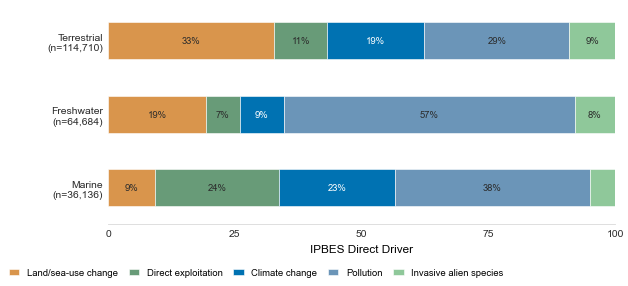

In [6]:
core_driver_summary = driver_summary.loc[
    driver_summary["realm"].isin(CORE_REALMS)
].copy()
core_driver_bar_figure = driver_realm_plotting.plot_driver_fractional_bars(
    core_driver_summary,
    driver_order=DRIVER_ORDER,
    realm_order=CORE_REALMS,
    driver_names=DRIVER_NAMES,
    realm_names=REALM_NAMES,
    realm_supports=realm_supports,
    driver_colors=DRIVER_COLORS,
    figure_height=2.9,
    show_segment_labels=True,
    segment_label_min_pct=6.0,
)
save_figure(
    core_driver_bar_figure, REALM_CONFIG["l1_core_realm_bar_figure_filename"]
)
plt.show()

## 3. The supplementary figure

`realm_trends.pdf` — Supplementary Figure `sfig:realm_trends`. Three panels over
2000–2025, one line per core realm: **(a)** pollution as a share of driver attributions,
**(b)** the share of pollution articles using plastic or marine-debris terminology, and
**(c)** direct exploitation as a share of driver attributions. Panels (a) and (c) use the
same publication-fractional rule as the manuscript figure — a publication carrying \(k\)
drivers contributes \(1/k\) to each.

The plastics denominator is pollution-tagged publications with available title or abstract
text. The case-insensitive regex captures `plastic(s)`, `microplastic(s)`,
`nano-plastic(s)`, plastic debris/waste/litter/particles/fibres/pellets/fragments/pollution,
and marine or anthropogenic debris/litter; word boundaries prevent `plasticity` from
matching.

Fractional-binomial logit models estimate the 2000–2025 endpoint changes and odds ratios
per decade; `q` controls the false-discovery rate across the nine realm–outcome trends.
These are attention and terminology trends, not tests of ecological impact.

'                                 outcome       realm  n_denominator_total  fitted_start_pct  fitted_end_pct  change_pp  odds_ratio_per_decade  q_trend\n          Pollution fractional attention Terrestrial               114710             31.48           27.36      -4.13                   0.92     0.00\n          Pollution fractional attention  Freshwater                64684             56.70           57.68       0.98                   1.02     0.21\n          Pollution fractional attention      Marine                36136             38.96           38.04      -0.92                   0.98     0.34\n               Plastics within pollution Terrestrial                36799              0.12            9.49       9.37                   5.94     0.00\n               Plastics within pollution  Freshwater                40488              0.03           13.52      13.49                  11.70     0.00\n               Plastics within pollution      Marine                15614              

✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/03_realm_composition/figures/pollution_plastics_exploitation_trends_core_realms.pdf


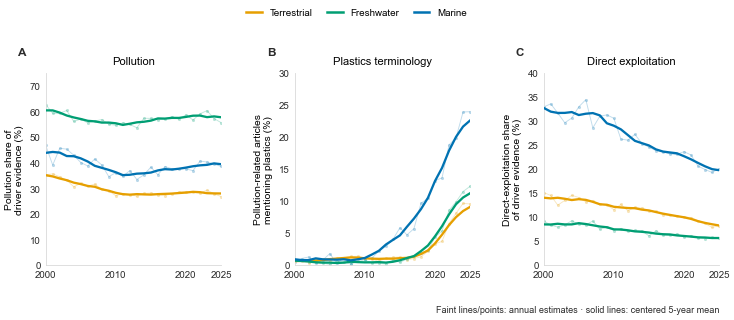

In [7]:
nameability_evidence = driver_realm.prepare_pollution_nameability_evidence(
    prepared.evidence,
    corpus_df,
    realm_order=CORE_REALMS,
    plastics_pattern=PLASTICS_PATTERN,
)
nameability_annual = driver_realm.annual_pollution_nameability_summary(
    nameability_evidence,
    realm_order=CORE_REALMS,
)
nameability_tests = driver_realm.pollution_nameability_trend_tests(
    nameability_annual,
    start_year=START_YEAR,
    end_year=END_YEAR,
)
outcome_order = [
    "Pollution fractional attention",
    "Plastics within pollution",
    "Direct exploitation fractional attention",
]
display(
    nameability_tests.assign(
        outcome_rank=lambda frame: frame["outcome"].map(
            {outcome: position for position, outcome in enumerate(outcome_order)}
        ),
        realm_rank=lambda frame: frame["realm"].map(
            {realm: position for position, realm in enumerate(CORE_REALMS)}
        ),
    )
    .sort_values(["outcome_rank", "realm_rank"])
    [[
        "outcome", "realm", "n_denominator_total", "fitted_start_pct",
        "fitted_end_pct", "change_pp", "odds_ratio_per_decade", "q_trend",
    ]]
    .round(2)
    .to_string(index=False)
)

nameability_figure = driver_realm_plotting.plot_pollution_nameability_trends(
    nameability_annual,
    realm_order=CORE_REALMS,
    realm_names=REALM_NAMES,
    realm_colors=CORE_REALM_COLORS,
    start_year=START_YEAR,
    end_year=END_YEAR,
)
save_figure(
    nameability_figure, REALM_CONFIG["pollution_nameability_figure_filename"]
)
plt.show()

## 4. Export

The realm article counts and exclusion audit, the core-realm driver composition behind the
manuscript figure, the full driver × realm summary, and the trend tests with their annual
series.

In [8]:
core_driver_composition = core_driver_summary.pivot(
    index="driver", columns="realm", values="fractional_share_pct"
)[list(CORE_REALMS)]

for table, filename, index in (
    (realm_counts, "realm_article_counts", False),
    (prepared.realm_exclusions, "realm_exclusion_audit", False),
    (core_driver_composition.reset_index(), "core_realm_driver_composition", False),
    (driver_summary, "driver_realm_summary", False),
    (nameability_tests, "realm_trend_tests", False),
    (nameability_annual, "realm_trend_annual", False),
):
    save_table(table, filename, index=index)
for path in sorted(FIGURE_DIR.glob("*.pdf")):
    print(path.relative_to(PROJECT_ROOT))

Saved: notebooks/results/outputs/03_realm_composition/csv/realm_article_counts.csv
Saved: notebooks/results/outputs/03_realm_composition/csv/realm_exclusion_audit.csv
Saved: notebooks/results/outputs/03_realm_composition/csv/core_realm_driver_composition.csv
Saved: notebooks/results/outputs/03_realm_composition/csv/driver_realm_summary.csv
Saved: notebooks/results/outputs/03_realm_composition/csv/realm_trend_tests.csv
Saved: notebooks/results/outputs/03_realm_composition/csv/realm_trend_annual.csv
notebooks/results/outputs/03_realm_composition/figures/l1_driver_composition_core_realms.pdf
notebooks/results/outputs/03_realm_composition/figures/pollution_plastics_exploitation_trends_core_realms.pdf
